In [1]:
## Installation required
## In qbraid we need to run the cell everytime we open a new session

!pip install qiskit[visualization]
# Use the following if you are on MacOS/zsh
#!pip install 'qiskit[visualization]'==1.1.0
!pip install qiskit_ibm_runtime
!pip install qiskit_aer
!pip install matplotlib
!pip install pylatexenc
!pip install prototype-zne

!pip install --upgrade qiskit-aer

In [2]:
import qiskit
qiskit.__version__

'2.5.1'

In [3]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator, QasmSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
import time

In [4]:
def qc_inp(qc, r_inp, input_binary, n):
    for i in range(n):
        if (input_binary[i] == "1"):
            qc.x(r_inp[i])

In [5]:
def key_gen2(qc, qr, round, n):
    for i in range(round): #1152
        qc.cx(qr[65],qr[92])
        qc.ccx(qr[90],qr[91],qr[92])
        qc.cx(qr[170],qr[92])
        qc.swap(qr[92],t[0])
        
        qc.cx(qr[161],qr[176])
        qc.ccx(qr[174],qr[175],qr[176])
        qc.cx(qr[263],qr[176])
        qc.swap(qr[176],t[1])
        
        qc.cx(qr[242],qr[287])
        qc.ccx(qr[285],qr[286],qr[287])
        qc.cx(qr[68],qr[287])
        qc.swap(qr[287],t[2])

        for j in range(287,176,-1):
            #print (j)
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])

        for j in range(176,92,-1):
            #print (j-1)
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(92,-1,-1):
            #print (j-1)
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])


    """ Key Stream Generation """
    for i in range(n):        
        qc.cx(qr[65],qr[92])
        qc.swap(qr[92],t[0])
        
        qc.cx(qr[161],qr[176])
        qc.swap(qr[176],t[1])
        
        qc.cx(qr[242],qr[287])
        qc.swap(qr[287],t[2])
        
        """z.append( XOR(XOR(t0,t1), t2) )  #To update"""
        qc.cx(t[0],z[i])
        qc.cx(t[1],z[i])
        qc.cx(t[2],z[i])
        
        qc.ccx(qr[90],qr[91],t[0]) #To update
        qc.cx(qr[170],t[0]) #To update
        
        qc.ccx(qr[174],qr[175],t[1]) #To update
        qc.cx(qr[263],t[1]) #To update
        
        qc.ccx(qr[285],qr[286],t[2]) #To update
        qc.cx(qr[68],t[2]) #To update
        
        for j in range(287,176,-1):
            #print (j)
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])

        for j in range(176,92,-1):
            #print (j-1)
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(92,-1,-1):
            #print (j-1)
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])


def rev_key_gen2(qc, qr, round, n):

    for i in range(n):
        
        for j in range(0,93,1): #To update the entire loop
            #print (j-1)
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])
        
        
        for j in range(93,177,1): #To update the entire loop
            #print (j-1)
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(177,288,1): #To update the entire loop
            #print (j)
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])
        
        qc.cx(qr[68],t[2]) #To update
        qc.ccx(qr[285],qr[286],t[2]) #To update
        
        qc.cx(qr[263],t[1]) #To update
        qc.ccx(qr[174],qr[175],t[1]) #To update
        
        qc.cx(qr[170],t[0]) #To update
        qc.ccx(qr[90],qr[91],t[0]) #To update
        
        
        qc.cx(t[2],z[n-1-i])
        qc.cx(t[1],z[n-1-i])
        qc.cx(t[0],z[n-1-i])
        
        qc.swap(qr[287],t[2])
        qc.cx(qr[242],qr[287])
        
        qc.swap(qr[176],t[1])
        qc.cx(qr[161],qr[176])
        
        qc.swap(qr[92],t[0])
        qc.cx(qr[65],qr[92])
            
    
    for i in range(round): #1152
        
        for j in range(0,93,1):
            #print (j-1)
            if j == 0:
                qc.swap(qr[0], t[2])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(93,177,1):
            #print (j-1)
            if j == 93:
                qc.swap(qr[93], t[0])
            else:
                qc.swap(qr[j], qr[j-1])
        
        for j in range(177,288,1):
            #print (j)
            if j == 177:
                qc.swap(qr[177], t[1])
            else:
                qc.swap(qr[j], qr[j-1])
        
        qc.swap(qr[287],t[2])
        qc.cx(qr[68],qr[287])
        qc.ccx(qr[285],qr[286],qr[287])
        qc.cx(qr[242],qr[287])
        
        qc.swap(qr[176],t[1])
        qc.cx(qr[263],qr[176])
        qc.ccx(qr[174],qr[175],qr[176])
        qc.cx(qr[161],qr[176])
        
        qc.swap(qr[92],t[0])
        qc.cx(qr[170],qr[92])
        qc.ccx(qr[90],qr[91],qr[92])
        qc.cx(qr[65],qr[92])
        

In [6]:
def my_oracle(qc, r_key, r_ancilla, rev_ks, z, r_output, n, rnd, x):
    #Preparing key in a superposition state
    for i in range(n): #For loading Key and IV
        qc.cx(r_key[i], qr[36+i])
    key_gen2(qc, qr, rnd, n+x)
    
    #Checking whether the generated cipher text is equal to the given cipher text
    for i in range(n+x):
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(z[i], r_ancilla[i]) #r_text is z here
        qc.x(r_ancilla[i])
        
    #Set 'output' bit if the cipher text is matched
    qc.mcx(r_ancilla, r_output)
    
    qc.barrier()
    
    #Uncompute cipher to reset ancilla & plain text qubits
    #Reset ancilla qubit
    for i in range(n+x):
        qc.x(r_ancilla[i])
        qc.cx(rev_ks[i], r_ancilla[i])
        qc.cx(z[i], r_ancilla[i]) #r_text is z here
    qc.barrier()
    
    rev_key_gen2(qc, qr, rnd, n+x)
    for i in range(n): #For loading Key and IV
        qc.cx(r_key[i], qr[36+i])
    qc.barrier()
        

In [7]:
#The diffuser function is available in Qiskit; Courtesey: https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/grover.ipynb
# and https://www.youtube.com/watch?v=eyAAII_WsQs 
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    #nqubits = nqubits - 2
    #Apply transformation |s> -> |00...0> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #Apply transformation |00...0> -> |11...1> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)    
    #Do multi-controlled Z gate
    qc.h(nqubits - 1)
    qc.mcx(list(range(nqubits - 1)), nqubits - 1) #multi-controlled Toffoli
    qc.h(nqubits - 1)
    #Apply transformation |11...1> -> |00...0> (X gates)
    for qubit in range(nqubits):
        qc.x(qubit)
    #Apply transformation |00...0> -> |s> (H gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    #We will return the diffuser as a gate
    U_s = qc.to_gate()
    U_s.name = "U$_s$"
    return U_s
    

In [ ]:
n = 6 #No. of key qubits to recover
rnd = 1152
x = 0 #x denotes the additional length of the key stream, other than key length, n. If key stream length is n+5, then x = 5
qr = QuantumRegister(288) #test Quantum Register is useless here, just used for any test purpose
#temp = QuantumRegister(1)
t = QuantumRegister(3)
z = QuantumRegister(n+x)
#r_text = QuantumRegister(n+3, 't')
r_key = QuantumRegister(n, 'k')
r_output = QuantumRegister(1, name = 'o')
rev_ks = QuantumRegister(n+x, 'c')
r_ancilla = QuantumRegister(n+x, 'a')

r_class = ClassicalRegister(n)

qc = QuantumCircuit(qr,t,z, r_key, rev_ks, r_ancilla, r_output, r_class)

#loading known cipher text
ks_actual = '001011'       # Spurious Keys: '011111' and '101000'
qc_inp(qc, rev_ks, ks_actual, n+x) #Thus we get the key stream in rev_ks; actual ks='001'
#for i in range(n):
#    qc.cx(r_text[i], rev_ks[i]) #Thus we get the key stream in rev_ks

for i in range(n):
    qc.h(r_key[i])

### Initialization of s array ###
key_0_35 = '000000010010001101000101011001111000' #len=36
#key_36_37_38 = '011'
#key_to_find -> key-36-37-38 -> Actual key-value = '001', len=3; Actual z-value (ks) = '010111' for 200 rounds and KS size = 6
#key_36_37_38_39_40 = '00000'
#key_to_find -> key-36-37-38 -> Actual key-value = '1010', len=4; Actual z-value (ks) = '0111' for 200 rounds and KS size = 4
key_42_79 = '10101111001101111011110001001000110100' #len=38
#key_39_79 = '11010101111001101111011110001001000110100' #len=41
for i in range(36): #For loading Key
    if (key_0_35[i] == "1"):
        qc.x(qr[i+0]) 
for i in range(38): #For loading Key
    if (key_42_79[i] == "1"):
        qc.x(qr[i+42])

"""for i in range(5): #For loading Key
    if (key_36_37_38_39_40[i] == "1"):
        #qc.x(r_key[i])
        qc.x(qr[i+36])"""

iv = '00000001001000110100010101100111100010011010101111001101111011110001001000110100'
for i in range(80): #For loading IV
    if (iv[i] == "1"):
        qc.x(qr[i+93]) 

qc.x(qr[285])
qc.x(qr[286])
qc.x(qr[287])
### End of Initialization ###

#Preparing output qubit
qc.x(r_output)
qc.h(r_output)
qc.barrier()

start = time.perf_counter()
#First Iteration
my_oracle(qc, r_key, r_ancilla, rev_ks, z, r_output, n, rnd, x)
qc.barrier()
qc.append(diffuser(n), r_key)
#qc.barrier()

#Second Iteration
my_oracle(qc, r_key, r_ancilla, rev_ks, z, r_output, n, rnd, x)
qc.barrier()
qc.append(diffuser(n), r_key)
qc.barrier()

qc.measure(r_key, r_class) #qc.measure(z, r_class) 
print("Circuit depth: ", qc.depth())

Circuit depth:  449762


In [9]:
# Simulate the quantum circuit
backend = AerSimulator(method='matrix_product_state') # 'automatic' or 'matrix_product_state', 'density_matrix' (but only 'matrix_product_state' is working for select = 7; for other options simulation fails)
n_o_shots = 1024
tcirc = transpile(qc)
#qcd = qc.decompose(reps=5)
qcd = tcirc.decompose(reps=5) # Use this in place of above when we use 'tcirc = transpile(qc)'
result = backend.run(qcd, shots=n_o_shots).result() 
print("Wall-time elapsed (in sec):", time.perf_counter() - start)
## Plot results
counts = result.get_counts()
print (counts)


Wall-time elapsed (in sec): 77747.65593579994
{'100010': 4, '001011': 7, '111110': 302, '011110': 8, '001101': 5, '100100': 6, '111100': 5, '100101': 9, '111011': 6, '001110': 7, '101110': 9, '110010': 11, '000101': 332, '010111': 8, '101111': 9, '110001': 12, '010110': 11, '100000': 3, '101001': 6, '111111': 2, '100001': 8, '001010': 8, '010000': 9, '011101': 6, '010100': 6, '000000': 7, '100110': 9, '001111': 7, '111010': 3, '001100': 3, '111101': 7, '100011': 3, '110110': 4, '101010': 5, '000001': 12, '011010': 11, '000010': 7, '110101': 6, '101011': 6, '000111': 2, '110000': 9, '001001': 8, '010011': 4, '010010': 10, '000011': 3, '110100': 7, '101100': 8, '111001': 3, '010101': 8, '011111': 6, '011100': 6, '110011': 8, '101101': 9, '000100': 9, '101000': 4, '011011': 5, '011001': 5, '010001': 6, '011000': 3, '100111': 6, '111000': 4, '001000': 2}


Key is : 101000 with probability = 0.32421875 and count = 332


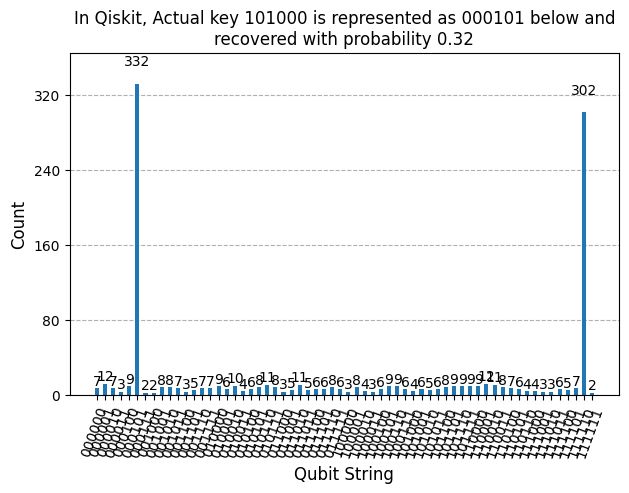

In [10]:
b, c = max(counts.items(), key=lambda x: x[1])
print("Key is :", b[::-1], "with probability =", c/n_o_shots, "and count =", c)

%matplotlib inline
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

figure = plot_histogram(counts, title = "In Qiskit, Actual key {0} is represented as {1} below and\nrecovered with probability {2:.2f}".format(b[::-1],b,c/n_o_shots))
# Label the axes
ax = figure.gca()  # Get the current axis
ax.set_xlabel('Qubit String', fontsize=12)  # Set x-axis label
ax.set_ylabel('Count', fontsize=12)  # Set y-axis label

# Save the plot as an image
figure.savefig("histogram.png")